# Algorithms for improving the b-chromatic colouring

## Packages

In [161]:
import networkx as nx
import itertools, random
import matplotlib.pyplot as plt
from b_chromatic_utils import *
from b_chromatic_colouring import get_m_degree, get_dense_vertices, get_m_degree_2
from bipartite_matching import getH, getColourMaps ,bipartite_matching, getNXgraph
import pandas as pd
import copy
import time
import os

## Helpers functions

In [2]:
def is_proper(G, c):
    for u,v in G.edges():
        if((c[u] is not None and c[v] is not None) and (c[u] == c[v])):
            return False
    return True

In [3]:
def get_b_chromatic_vertices(G, c):
    C = set(list(c.values()))
    b_chr_list = []
    for u in G.nodes():
        cNu = {c[v] for v in G.adj[u]}
        if len(cNu) == len(C)-1: b_chr_list.append(u)
    return b_chr_list


## Partition redistribution algorithm (heuristic)

In [4]:
max([(3,2), (2,3)], key=lambda x:x[0])

(3, 2)

In [229]:
def partition_redistribution(G, f):
    C = set(list(f.values()))
    fp = f.copy()
    Cp = C.copy()
    CnV = {c:1 for c in C}#initially every colour has one vertex
    #V = {u:G.degree(u) for u in G}
    #V = sorted(V.items(), key=lambda x:x[1])
    #V = list(zip(*V))[0]
    V = list(G.nodes())
    random.shuffle(V)
    for c in C:
        Vc = {u for u in V if fp[u] == c}
        Vcp = Vc.copy()
        vertices_to_recolour = {}
        for v in Vc:
            cNv = {fp[u] for u in G.adj[v]}
            if len(cNv) < len(Cp)-1:
                CNv = {cp: CnV[cp] for cp in Cp.difference(cNv.union(set([c])))}
                assert CNv != set()
                cp = min(CNv.items(), key=lambda x:x[1])[0]
                vertices_to_recolour[v] = cp
                Vcp.remove(v)
        if Vcp == set():
            for v, cp in vertices_to_recolour.items():
                fp[v] = cp
                CnV[cp] += 1
            Cp.remove(c)
    #print("New set of colours: {}".format(set(list(fp.values()))))
    return fp

In [492]:
def get_b_chromaticness(G, f, C):
    """ Get the b-chromaticness for every colour, i.e., how close to have a b-chromatic vertex a colour is
        G: Graph,
        f: colour assignation function
        C: Set of colours
    """
    b_chromatic = {c:False for c in C}
    BC = {c:-1 for c in C}
    for c in C:
        for u in G:
            if f[u] == c:
                bc = len({f[v] for v in G[u] if f[v] is not None})
                if bc > BC[c]:
                    BC[c] = bc
        if BC[c] == len(C)-1: b_chromatic[c] = True
    return BC, b_chromatic


In [196]:
def get_neighbourhood_presency_matrix(G, f):
    NP = {u:{c:False for c in set(f.values())} for u in G}
    for u in G:
        for v in G[u]:
            NP[u][f[v]] = True
    return NP

In [257]:
def is_there_not_realized_colour(C, BC):
    #print(BC)
    min_chromaticness_c = min(BC.items(), key=lambda x:x[1])[0]
    if BC[min_chromaticness_c] == len(C)-1: return False
    else: return min_chromaticness_c

In [ ]:
def find_minimum_not_realized_colour(C, BC):
    min_not_realized = False
    min_c = list(BC.keys())[0]
    for c in C:
        if BC[min_c] > BC[c]:
            min_c = c

### Changes to the PR heuristic

In [498]:
def partition_redistribution2(G, f):
    C = set(list(f.values()))
    fp = f.copy()
    Cp = C.copy()
    CnV = {c:1 for c in C}#initially every colour has one vertex
    #V = {u:G.degree(u) for u in G}
    #V = sorted(V.items(), key=lambda x:x[1])
    #V = list(zip(*V))[0]
    V = list(G.nodes())
    BC, _ = get_b_chromaticness(G, f, Cp)
    random.shuffle(V)
    while(True):
        c = is_there_not_realized_colour(Cp, BC)
        if c is False: break
        #print("Deleting colour: {}".format(c))
        Vc = {u for u in V if fp[u] == c}
        Vcp = Vc.copy()
        vertices_to_recolour = {}
        for v in Vc:
            cNv = {fp[u] for u in G.adj[v]}
            if len(cNv) < len(Cp)-1:
                CNv = {cp: CnV[cp] for cp in Cp.difference(cNv.union(set([c])))}
                assert CNv != set()
                cp = min(CNv.items(), key=lambda x:x[1])[0]
                vertices_to_recolour[v] = cp
                Vcp.remove(v)
        if Vcp == set():
            for v, cp in vertices_to_recolour.items():
                fp[v] = cp
                CnV[cp] += 1
            Cp.remove(c)
            BC, _ = get_b_chromaticness(G, fp, Cp)
    #print("New set of colours: {}".format(set(list(fp.values()))))
    return fp

In [512]:
def partition_redistribution3(G, f):
    C = set(list(f.values()))
    fp = copy.deepcopy(f)
    Cp = copy.deepcopy(C)
    #V = {u:G.degree(u) for u in G}
    #V = sorted(V.items(), key=lambda x:x[1])
    #V = list(zip(*V))[0]
    BC, _ = get_b_chromaticness(G, fp, C)
    NP = get_neighbourhood_presency_matrix(G, fp)
    V = list(G.nodes())
    random.shuffle(V)
    #for c in C:
    while(True):
        c = is_there_not_realized_colour(Cp, BC)
        if c == False: break
        #print("Deleting colour {}".format(c))
        #print(BC)
        Vc = {u for u in V if fp[u] == c}
        Vcp = Vc.copy()
        vertices_to_recolour = {}
        for v in Vc:
            cNv = {fp[u] for u in G.adj[v]}
            if len(cNv) < len(Cp)-1:
                #here is where we distinguish between candidates and helpers
                if G.degree(v) >= len(Cp)-1:#v is a candidate
                    #we'll assign v the colour that's more close to become b-chromatic
                    BCp = {cpp:BC[cpp] for cpp in Cp.difference(cNv.union({c}))}
                    cp = max(BCp.items(), key=lambda x:x[1])[0]
                else:#v is a helper
                    #we'll assign v the colour that appear less times in the neighbourhood of the neighbours of v
                    NPc = {cpp:0 for cpp in Cp.difference(cNv.union({c}))}
                    for cpp in NPc:
                        for u in G[v]:
                            #if colour c is on the neighbourhood of u
                            if NP[u][cpp]: NPc[cpp] += 1
                    cp  = min(NPc.items(), key=lambda x:x[1])[0]
                    #We pick the colour with highest priority here
                    #bcmin = min(BC.items(), key=lambda x:x[1])[0]
                    #while(len(NPc) >= 1):
                    #    cp  = min(NPc.items(), key=lambda x:x[1])[0]
                    #    if BC[cp] <= BC[bcmin]:break
                    #    else: NPc.pop(cp)
                vertices_to_recolour[v] = cp
                Vcp.remove(v)
        if Vcp == set():
            for v, cp in vertices_to_recolour.items():
                #print("  Changing the colour of {} from {} to {}".format(v, c, cp))
                fp[v] = cp
            Cp.remove(c)
            BC, _ = get_b_chromaticness(G, fp, Cp)
            NP = get_neighbourhood_presency_matrix(G, fp)
    #print("New set of colours: {}".format(set(list(fp.values()))))
    return fp

### Testing on a random graph

Number of colours: 10


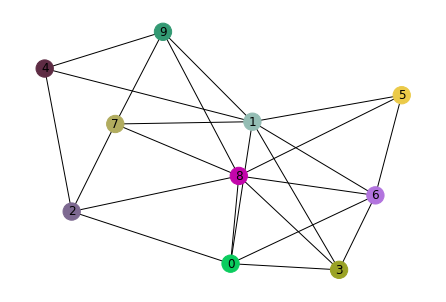

In [308]:
G = nx.random_graphs.gnp_random_graph(10, 0.5)
f = {u:i+1 for i, u in enumerate(G.nodes())}
C = set(f.values())
print("Number of colours: {}".format(len(set(list(f.values())))))
nx.draw(G, with_labels=True, node_color=get_colors_to_use(f))

In [248]:
f

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10}

In [489]:
G = nx.random_graphs.gnp_random_graph(50, 0.5)
f = {u:i+1 for i, u in enumerate(G.nodes())}
print("m(G): {}".format(get_m_degree(G)))
fp = partition_redistribution2(G, f)
Vp = get_b_chromatic_vertices(G, fp)
assert is_proper(G, fp)
assert are_b_chromatic(G, fp, Vp)
print("Number of colours: {}".format(len(set(list(fp.values())))))

m(G): 25
Number of colours: 12


In [344]:
fp

{0: 8, 1: 10, 2: 3, 3: 8, 4: 5, 5: 6, 6: 6, 7: 8, 8: 9, 9: 10}

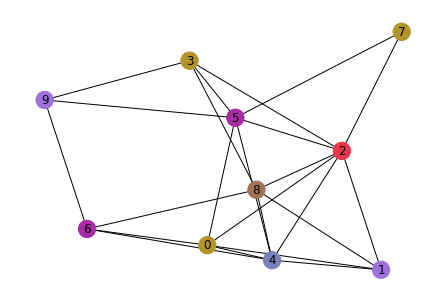

In [345]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(fp))

In [346]:
Vp = get_b_chromatic_vertices(G, fp)
C = set(fp.values())
Vp, C

([2, 4, 8], {3, 5, 6, 8, 9, 10})

We compare the number of colours used and the m-degree of $G$

In [10]:
len(C), get_m_degree(G)

(4, 6)

### Testing on a small graph 2

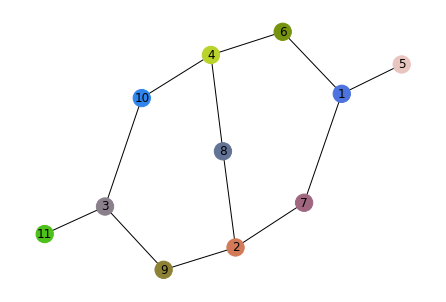

In [41]:
G = nx.Graph()
G.add_edges_from([(1,5), (1,6), (1,7), (2,7), (2,8), (2,9), (3,9), (3,10), (3,11), (4,6), (4,8), (4,10)])
f = {u:u for u in G.nodes()}
nx.draw(G, with_labels=True, node_color=get_colors_to_use(f))

In [43]:
m = get_m_degree(G)
fp = partition_redistribution(G, f)
assert is_proper(G, fp)
print("Number of colours: {}".format(len(set(list(fp.values())))))
print("m(G) = {}".format(m))
print("b-chromatic vertices: {}".format(get_b_chromatic_vertices(G, fp)))
print("Dense vertices: {}".format(get_dense_vertices(G, get_m_degree(G))))

Original set of colours: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
New set of colours: {8, 10, 11}
Number of colours: 3
m(G) = 4
b-chromatic vertices: [1, 6, 7, 2, 8, 9, 3, 10, 4]
Dense vertices: [1, 2, 3, 4]


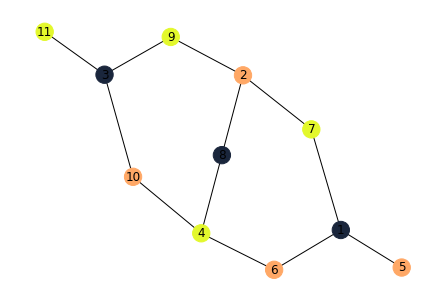

In [45]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(fp))

### Testing on a bunch of random graph with given number of vertices

In [46]:
df_res = {  "n":[], 
            "#colours_used":[], 
            "m_degree_G":[],
            "#dense_vertices":[],
            "#b_chromatic_vertices":[],
            "#dense_non_b_chro":[],
            "#dense_b_chro":[],
            "#non_dense_b_chro":[]}
k = 1
for n in range(50, 1050, 50):
    colours_used_avg = 0
    m_avg = 0
    n_dense_avg = 0
    b_chro_avg = 0
    n_dense_non_b_chro = 0
    n_dense_b_chro = 0
    n_non_dense_b_chro = 0
    for i in range(k):
        Gi = nx.random_graphs.gnp_random_graph(n, 0.50)
        mi = get_m_degree(Gi)
        Vpi = get_dense_vertices(Gi, mi)
        fi = {u:j+1 for j, u in enumerate(Gi.nodes())}
        fpi = partition_redistribution(Gi, fi)
        assert is_proper(Gi, fpi)
        V_b_chro = get_b_chromatic_vertices(Gi, fpi)
        Ci = set(fpi.values())
        colours_used_avg += len(Ci)
        m_avg += mi
        n_dense_avg += len(Vpi)
        b_chro_avg += len(V_b_chro)
        n_dense_non_b_chro += len(set(Vpi).difference(set(V_b_chro)))
        n_dense_b_chro += len(set(Vpi).intersection(set(V_b_chro)))
        n_non_dense_b_chro += len(set(V_b_chro).difference(set(Vpi)))
    df_res["n"].append(n)
    df_res["#colours_used"].append(colours_used_avg/k)
    df_res["m_degree_G"].append(m_avg/k)
    df_res["#dense_vertices"].append(n_dense_avg/k)
    df_res["#b_chromatic_vertices"].append(b_chro_avg/k)
    df_res["#dense_non_b_chro"].append(n_dense_non_b_chro)
    df_res["#dense_b_chro"].append(n_dense_b_chro)
    df_res["#non_dense_b_chro"].append(n_non_dense_b_chro)
df_res = pd.DataFrame(df_res)


Original set of colours: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50}
New set of colours: {37, 39, 40, 41, 42, 43, 44, 45, 47, 48, 49, 50}
Original set of colours: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100}
New set of colours: {76, 79, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 96, 97, 98, 99, 100}
Original set of colours: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 4

In [47]:
df_res

,n,#colours_used,m_degree_G,#dense_vertices,#b_chromatic_vertices,#dense_non_b_chro,#dense_b_chro,#non_dense_b_chro
0,50,12.0,26.0,29.0,36.0,4,25,11
1,100,21.0,51.0,60.0,54.0,22,38,16
2,150,27.0,75.0,78.0,96.0,20,58,38
3,200,34.0,101.0,107.0,128.0,25,82,46
4,250,43.0,126.0,135.0,105.0,57,78,27
5,300,48.0,151.0,166.0,138.0,74,92,46
6,350,56.0,176.0,194.0,158.0,96,98,60
7,400,61.0,200.0,206.0,195.0,91,115,80
8,450,68.0,224.0,228.0,184.0,119,109,75
9,500,73.0,249.0,265.0,265.0,108,157,108


In [2]:
df_res = pd.read_csv("./partition_redistribution_results/18_9_2023_16_2_stats.csv", sep=",", index_col=0)

In [3]:
df_res

,n,#colours_used,m_degree_G,#dense_vertices,#b_chromatic_vertices,#dense_non_b_chro,#dense_b_chro,#non_dense_b_chro
0,50,12.6,25.3,29.7,29.1,8.2,21.5,7.6
1,100,20.6,50.5,54.5,56.3,17.0,37.5,18.8
2,150,28.3,75.5,80.9,76.1,33.0,47.9,28.2
3,200,34.6,100.8,108.4,110.8,37.3,71.1,39.7
4,250,42.6,125.5,133.7,117.9,58.7,75.0,42.9
5,300,47.6,150.1,157.1,154.2,63.0,94.1,60.1
6,350,55.1,175.1,183.1,167.0,85.0,98.1,68.9
7,400,61.0,200.4,207.6,188.8,95.1,112.5,76.3
8,450,66.7,224.8,233.2,217.3,102.8,130.4,86.9
9,500,74.8,250.2,261.5,227.5,125.4,136.1,91.4


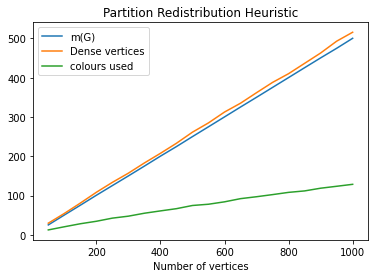

In [4]:
plt.plot(df_res["n"], df_res["m_degree_G"], label="m(G)")
plt.plot(df_res["n"], df_res["#dense_vertices"], label="Dense vertices")
plt.plot(df_res["n"], df_res["#colours_used"], label="colours used")
plt.xlabel("Number of vertices")
plt.title("Partition Redistribution Heuristic")
plt.legend(loc="best")
plt.show()


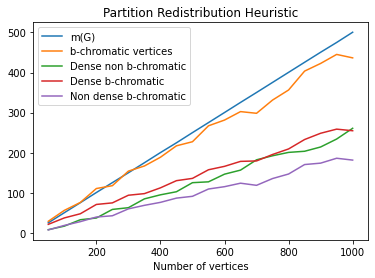

In [5]:
plt.plot(df_res["n"], df_res["m_degree_G"], label="m(G)")
plt.plot(df_res["n"], df_res["#b_chromatic_vertices"], label="b-chromatic vertices")
plt.plot(df_res["n"], df_res["#dense_non_b_chro"], label="Dense non b-chromatic")
plt.plot(df_res["n"], df_res["#dense_b_chro"], label="Dense b-chromatic")
plt.plot(df_res["n"], df_res["#non_dense_b_chro"], label="Non dense b-chromatic")
plt.xlabel("Number of vertices")
plt.title("Partition Redistribution Heuristic")
plt.legend(loc="best")
plt.show()

## Algorithm for improving the colouring obtained

First, we construct an algorithm and then find a initial b-chromatic colouring using the partition redistribution algorithm

In [36]:
n = 10
G = nx.random_graphs.gnp_random_graph(n, 0.50)
f = {u:j+1 for j, u in enumerate(G.nodes())}
#we get the partition redistribution colouring
fp = partition_redistribution(G, f)

#we check that the produced colouring is proper
assert is_proper(G, fp)

#we get the b-chromatic vertices
Vb = get_b_chromatic_vertices(G, fp)

#C is the set of colours
C = set(fp.values())
k = len(C)

#m-degree of G
m = get_m_degree(G)

#VR is the set of b-chromatic vertices with degree at least |C|; These vertices can receive one more colour
B1 = [u for u in Vb if G.degree[u] >= len(C)]# vertices to recolour
print("# of b-chromatic vertices: {}\n# of colours used: {}\nm(G): {}".format(len(Vb), len(C), m))
print("b-chormatic vertices with degree at least {}: {}".format(len(C), B1))

Original set of colours: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10}
New set of colours: {6, 7, 8, 9, 10}
# of b-chromatic vertices: 5
# of colours used: 5
m(G): 5
b-chormatic vertices with degree at least 5: [0, 1, 2, 3]


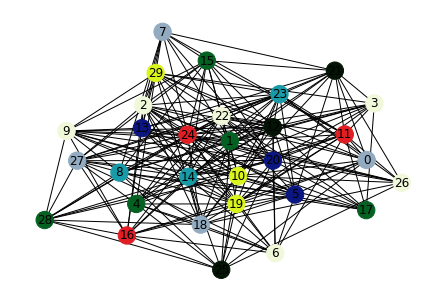

In [26]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(fp))

## Approach 1
We search for b-chromatic vertices all over the set $VR$ for all colours including the new one

In [11]:
k = len(C)
d = random.choice(list(set(f.values()).difference(C)))#we pick a random colour that have not been used yet
print("{}-th colour to be added: {}".format(k+1, d))
Cp = [c for c in C.union({d})]
Z = {c:0 for c in Cp}
R = {u:False for u in B1}
ffp = fp.copy()
for c in Cp:
    print("Searching for a b-chromatic vertex of colour {}: ".format(c), end="")
    i = 0
    while(Z[c] == 0 and i < len(B1)):
        u = B1[i]
        if (R[u] is False):
            H, A, B = getH(G, u, fp, c)
            M = bipartite_matching(H, A, B)
            color_map = getColourMaps(M)
            if len(color_map.keys()) == k:
                for w, colour in color_map.items():
                    ffp[w] = colour
                Z[c] = 1
                R[u] = True
        i += 1
    if Z[c] == 1: print("Found!")
    else: print("Not found.")
    
if sum(Z.values()) == k+1:
    print("The colouring c have been extended to a k+1 colours")

6-th colour to be added: 3
Searching for a b-chromatic vertex of colour 3: 

TypeError: getH() takes 3 positional arguments but 4 were given

In [46]:
Z

{3: 1, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0}

In [53]:
ffp

{0: 1,
 1: 1,
 2: 1,
 3: 13,
 4: 11,
 5: 1,
 6: 14,
 7: 1,
 8: 13,
 9: 14,
 10: 11,
 11: 12,
 12: 13,
 13: 14,
 14: 15}

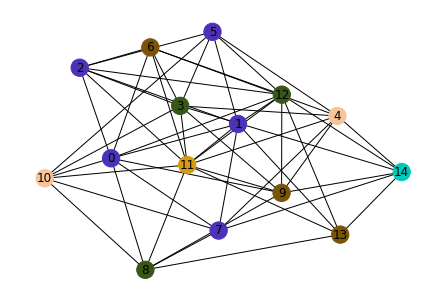

In [71]:
colours = get_colors_to_use(ffp)
nx.draw(G, with_labels=True, node_color=colours)

['#375718', '#F7C398', '#4D32B9', '#7C5408', '#4D32B9', '#7C5408', '#D49C0C', '#00C8BA']


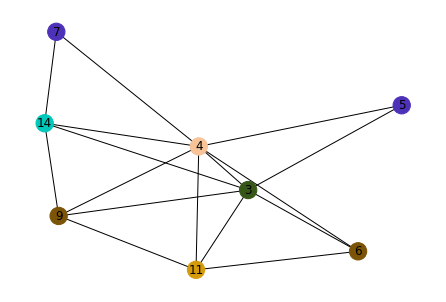

In [77]:
Gp = nx.subgraph(G, list(G.adj[4])+[4])
colours_p = [colours[u] for u in Gp]
print(colours_p)
nx.draw(Gp, with_labels=True, node_color=colours_p)

## Approach 2
We first search the b-chromatic vertex of colour $d$ and then try to add colour $d$ to the remaining b-chromatic vertices.

In order to do this we first have to define the spare b-chromatic vertices


In [126]:
def extend_colouring(G, B, D, C, F, f, d):
    """
    G: Graph
    B: b-chromatic flags for the vertices
    D: Set of vertices with degree at least |C|
    C: Set of colours used in the colouring f
    f: colour assignation function
    d: colour to be added to the colouring
    """
    k = len(C)
    Z = {c:False for c in C.union(set([d]))}
    counter = 0
    fc = f.copy()
    for u in D:
        if Z[fc[u]] is False or Z[d] is False:
            if  B[u] and F[f[u]] == 1: 
                Cp = C.difference(set([fc[u]])).union(set([d]))
            else:
                Cp = C
                dp = fc[u]
                fc[u] = d
            H, X, Y = getH(G, u, fc, Cp)
            M = bipartite_matching(H, X, Y)
            color_map = getColourMaps(M)
            if len(color_map.keys()) == k:
                print("Colour of {}: {} \n\t Assigning to N({}) colours: {}".format(u, fc[u], u, Cp))
                for w, colour in color_map.items(): fc[w] = colour
                Z[fc[u]] = True
                counter += 1
                B[u] = True
            elif (not B[u] or F[f[u]] >= 2):
                fc[u] = dp
    if counter == k+1: return fp, B, C.union({d}), True
    else: return f, B, C, False

In [129]:
n = 20
G = nx.random_graphs.gnp_random_graph(n, 0.50)
f = {u:j+1 for j, u in enumerate(G.nodes())}
#we get the partition redistribution colouring
fp = partition_redistribution(G, f)

#re indexing colours
g = {u:i+1 for i, u in enumerate(set(fp.values()))}
for u in G:
    f[u] = g[fp[u]]


#we check that the produced colouring is proper
assert is_proper(G, f)

#we get the b-chromatic vertices
Vb = get_b_chromatic_vertices(G, f)


#m-degree of G
m = get_m_degree(G)
print("m(G): {}".format(m))


Original set of colours: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20}
New set of colours: {10, 12, 13, 15, 16, 18, 19, 20}
m(G): 11


In [130]:
#C is the set of colours
C = set(f.values())
print("Colours that are used: {}".format(C))

#D is the set of vertices with degree at least |C|; These vertices can receive one more colour
D = [u for u in G if G.degree[u] >= len(C)]
print("Set of vertices with degree at least {}: {}".format(len(C), D))

#B is the set of b-chromatic vertices; B is represented by a boolean dictionary to allow constant lookup
B = {u: False for u in G}
for v in Vb: B[v] = True
print("Set of b-chromatic vertices: {}".format(Vb))

#we choose a random colour to extend the current colouring
d = len(C)+1#we pick a random colour that have not been used yet     
print("Colour to be added: {}".format(d))

#we keep a count on the number of b-chromatic vertices per colour
F = {c:0 for c in C}
for u in Vb: F[f[u]] += 1
print("# of b-chromatic vertices per colour: {}".format(F))

f, B, C, flag =extend_colouring(G, B, D, C, F, f, d)
flag
    

Colours that are used: {1, 2, 3, 4, 5, 6, 7, 8}
Set of vertices with degree at least 8: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Set of b-chromatic vertices: [1, 3, 4, 5, 6, 9, 10, 12, 15, 16, 17, 18, 19]
Colour to be added: 9
# of b-chromatic vertices per colour: {1: 1, 2: 1, 3: 2, 4: 1, 5: 3, 6: 2, 7: 1, 8: 2}
Colour of 0: 9 
	 Assigning to N(0) colours: {1, 2, 3, 4, 5, 6, 7, 8}
Colour of 2: 9 
	 Assigning to N(2) colours: {1, 2, 3, 4, 5, 6, 7, 8}
Colour of 4: 2 
	 Assigning to N(4) colours: {1, 3, 4, 5, 6, 7, 8, 9}
Colour of 6: 4 
	 Assigning to N(6) colours: {1, 2, 3, 5, 6, 7, 8, 9}
Colour of 11: 9 
	 Assigning to N(11) colours: {1, 2, 3, 4, 5, 6, 7, 8}
Colour of 12: 9 
	 Assigning to N(12) colours: {1, 2, 3, 4, 5, 6, 7, 8}
Colour of 15: 9 
	 Assigning to N(15) colours: {1, 2, 3, 4, 5, 6, 7, 8}
Colour of 19: 9 
	 Assigning to N(19) colours: {1, 2, 3, 4, 5, 6, 7, 8}


False

In [123]:
B

{0: False,
 1: True,
 2: True,
 3: True,
 4: True,
 5: True,
 6: True,
 7: False,
 8: True,
 9: True}

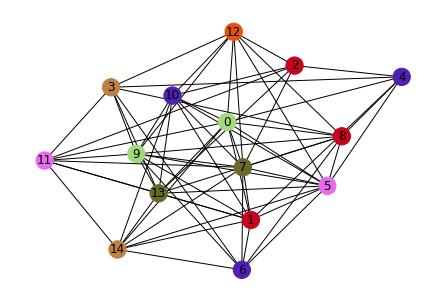

In [79]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(fp))

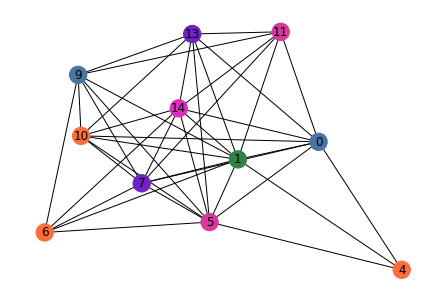

In [83]:
u = 1
Gp = nx.subgraph(G, list(G.adj[u])+[u])
gp1 = {u:fp[u] for u in Gp}
nx.draw(Gp, with_labels=True, node_color=get_colors_to_use(gp1))

In [86]:
gp1

{0: 10,
 1: 9,
 4: 11,
 5: 12,
 6: 11,
 7: 14,
 9: 10,
 10: 11,
 11: 12,
 13: 14,
 14: 15}

In [101]:
u = 1
for w in G[u]:
    if fp[u] not in {fp[wp] for wp in G[u] if wp != u}:
        print("It is possible to assign colour {} to {}".format(fp[u], w))

It is possible to assign colour 9 to 0
It is possible to assign colour 9 to 4
It is possible to assign colour 9 to 5
It is possible to assign colour 9 to 6
It is possible to assign colour 9 to 7
It is possible to assign colour 9 to 9
It is possible to assign colour 9 to 10
It is possible to assign colour 9 to 11
It is possible to assign colour 9 to 13
It is possible to assign colour 9 to 14


In [102]:
u, G[u]

(1,
 AtlasView({0: {}, 4: {}, 5: {}, 6: {}, 7: {}, 9: {}, 10: {}, 11: {}, 13: {}, 14: {}}))

In [98]:
N = {u:{c: True for c in C} for u in G}
for u in G:
    for v in G[u]: N[u][fp[v]] = False

In [99]:
for w in G[1]:
    if N[1][w][]:


{0: {9: False,
  10: True,
  11: False,
  12: False,
  13: False,
  14: False,
  15: False},
 1: {9: True, 10: False, 11: False, 12: False, 13: True, 14: False, 15: False},
 2: {9: True, 10: True, 11: False, 12: False, 13: False, 14: False, 15: True},
 3: {9: False,
  10: False,
  11: False,
  12: False,
  13: False,
  14: False,
  15: True},
 4: {9: False, 10: False, 11: True, 12: False, 13: True, 14: True, 15: False},
 5: {9: False,
  10: False,
  11: False,
  12: True,
  13: False,
  14: False,
  15: False},
 6: {9: False, 10: False, 11: True, 12: False, 13: True, 14: False, 15: False},
 7: {9: False,
  10: False,
  11: False,
  12: False,
  13: False,
  14: True,
  15: False},
 8: {9: True,
  10: False,
  11: False,
  12: False,
  13: False,
  14: False,
  15: False},
 9: {9: False,
  10: True,
  11: False,
  12: False,
  13: False,
  14: False,
  15: False},
 10: {9: False,
  10: False,
  11: True,
  12: False,
  13: False,
  14: False,
  15: False},
 11: {9: False, 10: False, 11:

## Approach 3

In [5]:
def spare_of_u(G, u, f, B):
    """Compute the spare vertices for vertex u
        G: Graph
        u: b-chromatic vertex
        f: colouring function
        B: flag for b-chromatic vertices under the colouring f
    """
    Su = {v: False for v in G.adj[u]}#set of spare vertices of u
    bNu = {c:0 for c in set(f.values())}#for counting how many b-chromatic vertices of colour are in N(u)
    cNu = {c:0 for c in set(f.values())}#colour set of N(u)
    for v in G.adj[u]:
        cNu[f[v]] += 1
        if B[v]: bNu[f[v]] += 1
    
    for v in G.adj[u]:
        if cNu[f[v]] >= 2:
            if not B[v]: Su[v] = True
            elif bNu[f[v]] >= 2: Su[v] = True
    return Su

def get_spare_vertices_of_B(G, B, f):
    """
        Compute the spare vertices of the b-chromatic vertices
        G: Graph
        B: Set of b-chromatic vertices
        f: colour assignment function
    """
    SB = {}
    for u in G:
        if B[u]:
            SB[u] = spare_of_u(G, u, f, B)
    return SB

def get_spare_vertices(G, B, SB):
    """ Compute the spare vertices of the graph
        G: Graph
        B: Set of b-chromatic vertices to consider
        SB: Set of spare vertices of each vertex in B as a dictorionary of flags"""
    S = {v:True for v in G}#initially all vertices are spare
    for v in G:
        for u in G.adj[v]:
            if B[u]: #if u is b-chromatic
                #if there v has a b-chromatic neighbour for which v is not spare then v is not a spare vertex
                if SB[u][v] == False: S[v] = False
    return S


### PREPROCESSING

In [181]:
def preprocessing(G, f):
    #Set of colours and number of colours
    C = set(f.values())
    k = len(C)

    #colours sorted by number of vertices
    CDu = {c:0 for c in C}
    for u in G: CDu[f[u]] += 1

    CDu = sorted(CDu.items(), key=lambda x:x[1])
    C = list(list(zip(*CDu))[0])

    #b-chromatic vertices
    Vb = get_b_chromatic_vertices(G, f)
    B = {u:False for u in G}
    for u in Vb: B[u]=True
    
    #set of b-chromatic vertices with degree at least k
    BD = {u:False for u in G}
    for u in G:
        if G.degree(u)>= k and B[u]: BD[u] = True

    #set of vertices sorted by degreee
    V = {u:G.degree(u) for u in G}
    V = sorted(V.items(), key=lambda x:x[1])
    V = list(zip(*V))[0]
    #print(V)

    #Set of colours for which there exists a vertex v with degree at least k
    Cp = set()
    for u in G:
        if G.degree(u): Cp.add(f[u])

    #Set of colours for which there is no vertex with degree at least k
    Cpp = [c for c in C if c not in Cp]

    #Set of fixed vertices (A fixed vertex is a vertex that should not change its colour)
    F = {u:False for u in G}

    return V, BD, C, Cp, Cpp, F

### COLOUR EXTENSION FUNCTIONS

In [59]:
def add_colour_k_plus_1(G, C, Cp, Cpp, V, f, BD, F, b_chromatic, bipartites_graphs):
    """ Adds colour |C|+1 to the neighbours of the b-chromatic vertices
        G: Graph
        C: Current set of colours
        Cp: Set of colours for which there exists b-chromatic vertices with degree at least |C|
        Cpp: Complement of Cp with respect to C
        V: Set of vertices sorted by degree in non descendant order
        f: colour assingment function
        BD: Set of b-chromatic vertices with degree at least |C|
        F: Set of fixed vertices
    """
    k = len(C)
    for c in Cp:
        #print("Looking for a b-chromatic vertex of colour {}".format(c))
        success = False
        for u in V:
            #print("Inspecting vertex {}".format(u))
            if BD[u] and not b_chromatic[u] and f[u] == c:
                NCu = [cp for cp in C+[k+1] if cp !=  f[u]]
                #NCu = C.difference({f[u]}).union({k+1})
                H, X, Y = getH(G, u, f, NCu, F)
                Hn = getNXgraph(H)
                M = nx.bipartite.maximum_matching(Hn, X)
                if len(M)/2 == k:
                    bipartites_graphs[c]["H"] = H
                    bipartites_graphs[c]["X"] = X
                    bipartites_graphs[c]["Y"] = Y
                    bipartites_graphs[c]["M"] = M
                    #print("Colour of {}: {} \n\t Assigning to N({}) colours: {}".format(u, f[u], u, NCu))
                    #print("\tb-chromatic vertex for colour {} found: {}".format(c, u))
                    for _ in range(k): 
                        w, cp = M.popitem()
                        cp = int(cp[1:])
                        w = int(w[1:])
                        f[w] = cp
                        F[w] = True
                        #print("\t f[{}] = {}".format(w, cp))
                    b_chromatic[u] = True
                    success = True
                    break
        if(not success): Cpp += [c]

    return f, Cpp, F, b_chromatic, bipartites_graphs

In [60]:
def find_b_chromatic_k_plus_1(G, V, C, Cpp, fc, F, b_chromatic, bipartites_graphs):
    """ Search for b-chromatic vertices for |C|+1 colours
        G: Graph
        V: Set of vertices sorted by degree in non descending order
        C: Current set of colours
        Vp: Set of candidates to become b-chromatic vertices
        Cpp: Set of colours for which there have not been found b-chromatic vertices by extending the colouring f
        fc: Colouring function
        F: Set of fixed vertices
        b_chromatic: Binary vector of b-chromatic vertices in the extended colouring
        bipartite_graphs: Store metadate about the assignation of colours
    """
    k = len(C)
    Vp = [u for u in V if G.degree(u) >= k and not b_chromatic[u]]
    for c in Cpp:
        #print("Looking for a b-chromatic vertex of colour {}".format(c))
        if len(Vp) == 0: break
        success = False
        for u in Vp:
            d = -1
            cNu = {cp:False for cp in C+[k+1]}
            for v in G[u]: cNu[fc[v]] = True
            if (fc[u] == c or (fc[u]!= c and not cNu[c])) and not F[u]:
                if fc[u] != c:
                    #print("We change the colour of {} from {} to {}".format(u, fc[u], c))
                    d = fc[u]
                    fc[u] = c
                NCu = [cp for cp in C+[k+1] if cp !=  fc[u]]
                #NCu = C.union({k+1}).difference({fc[u]})
                H, X, Y = getH(G, u, fc, NCu, F)
                Hn = getNXgraph(H)
                M = nx.bipartite.maximum_matching(Hn, X)
                if len(M)/2 == k:
                    bipartites_graphs[fc[u]]["H"] = H
                    bipartites_graphs[fc[u]]["X"] = X
                    bipartites_graphs[fc[u]]["Y"] = Y
                    bipartites_graphs[fc[u]]["M"] = M
                    #print("Colour of {}: {} \n\t Assigning to N({}) colours: {}".format(u, fc[u], u, NCu))
                    #print("\tb-chromatic vertex for colour {} found: {}".format(fc[u], u))
                    for _ in range(k): 
                        w, cp = M.popitem()
                        cp = int(cp[1:])
                        w = int(w[1:])
                        #print("\t f[{}] = {}".format(w, cp))
                        fc[w] = cp
                        F[w] = True
                    b_chromatic[u] = True
                    success = True
                    break
                elif d != -1: fc[u] = d
        if not success:
            #print("Not possible to find a b-chromatic colouring for colour {}".format(c))
            return success, fc, b_chromatic, F, bipartites_graphs
        else:
            Vp.remove(u)
    return True, fc, b_chromatic, F, bipartites_graphs

#### Version 1
#### (1) Add colour k+1 to the neighbourhood of the candidates
#### (2) Find a b-chromatic vertex of colour k+1

In [61]:
def extend_b_chromatic_colouring_by_one1(G, f):
    """Extend the colouring f of G by 1 maintaining the b-chromatic property
        G: Graph
    """
    print("PREPROCESSING", end="\r")
    V, BD, C, Cp, Cpp, F = preprocessing(G, f)

    #AUXILIAR DICTIONARY FOR BIPARTITE GRAPH H
    bipartites_graphs = {c:{"H":None, "X":None, "Y":None, "M":None} for c in C+[len(C)+1]}

    fc = copy.deepcopy(f)
    b_chromatic = {u:False for u in G}

    print("STAGE (1)", end="\r")
    fc, Cpp, F, b_chromatic, bipartites_graphs = add_colour_k_plus_1(G, C, Cp, Cpp, V, fc, BD, F,
                                                                     b_chromatic,
                                                                     bipartites_graphs)

    print("STAGE (2)", end="\r")
    Cpp = Cpp+[len(C)+1]
    success, fc, b_chromatic, F, bipartites_graphs = find_b_chromatic_k_plus_1( G, V, C, Cpp, fc, F, 
                                                                                b_chromatic, 
                                                                                bipartites_graphs)
    Bp = [u for u in G if b_chromatic[u]]

    if not success:
        print("NO EXTENSION!")
        return None
    else:
        if not is_proper(G, fc): 
            print("NO EXTENSION!")
            return None
        if not are_b_chromatic(G, fc, Bp): 
            print("NO EXTENSION!")
            return None
        print("COLOURING EXTENDED!")
        return fc

#### Version 2
#### (1) Find a b-chromatic vertex of colour k+1
#### (2) Add colour k+1 to the neighbourhood of the candidates

In [62]:
def extend_b_chromatic_colouring_by_one2(G, f):
    """Extend the colouring f of G by 1 maintaining the b-chromatic property
        G: Graph
    """
    print("PREPROCESSING", end="\r")
    V, BD, C, Cp, _, F = preprocessing(G, f)

    #AUXILIAR DICTIONARY FOR BIPARTITE GRAPH H
    bipartites_graphs = {c:{"H":None, "X":None, "Y":None, "M":None} for c in C+[len(C)+1]}

    fc = copy.deepcopy(f)
    b_chromatic = {u:False for u in G}

    print("STAGE (1)", end="\r")
    Cpp = [len(C)+1]
    success, fc, b_chromatic, F, bipartites_graphs = find_b_chromatic_k_plus_1( G, V, C, Cpp, fc, F, 
                                                                                b_chromatic, 
                                                                                bipartites_graphs)

    if not success:
        print("NO EXTENSION!")
        return
    
    print("STAGE (2)", end="\r")
    Cpp.pop()
    fc, Cpp, F, b_chromatic, bipartites_graphs = add_colour_k_plus_1(G, C, Cp, Cpp, V, fc, BD, F,
                                                                     b_chromatic,
                                                                     bipartites_graphs)
    if len(Cpp) > 0:
        print("STILL {} B-CHROMATIC VERTICES TO FOUND - NO EXTENSION!".format(len(Cpp)))
        print("STAGE (3)", end="\r")
        success, fc, b_chromatic, F, bipartites_graphs = find_b_chromatic_k_plus_1( G, V, C, Cpp, fc, F, 
                                                                                    b_chromatic, 
                                                                                    bipartites_graphs)
        
    Bp = [u for u in G if b_chromatic[u]]

    if not success:
        print("NO EXTENSION!")
        return None
    else:
        if not is_proper(G, fc): 
            print("NO PROPER COLOURING - NO EXTENSION!")
            return None
        if not are_b_chromatic(G, fc, Bp): 
            print("NOT ALL B-CHROMATIC - NO EXTENSION!")
            return None
        print("COLOURING EXTENDED!")
        return fc

### Function to extend the colouring as many times as possible

In [183]:
def extend_colouring(G, f, f_extension):
    """
        G: Graph,
        f: colouring function
        f_extension: function to extend the colouring
    """
    fc = copy.deepcopy(f)
    total_time = 0
    b_chr_ext = None
    while(True):
        start = time.time()
        fc = f_extension(G, fc)
        end = time.time()
        if fc is None: 
            if b_chr_ext is None: break
            #else: b_chr_ext += 1
            #break
        else:
            if b_chr_ext is None:
                b_chr_ext = len(set(fc.values()))
            else: b_chr_ext += 1
        total_time += end-start
    if b_chr_ext is None: return 0, total_time
    else: return b_chr_ext, total_time

### TESTING EXTENSION

#### TEST 1: 
#####  (1) FIND A B-CHROMATIC VERTEX FOR COLOUR K+1
#####  (2) ADD COLOUR K+1 TO THE NEIGHBOURHOOD OF THE CANDIDATES
####   (3) [Additionally] FIND B-CHROMATIC VERTICES OF REMAINING COLOURS OF STEP (2)


In [820]:
n = 10
G = nx.random_graphs.gnp_random_graph(n, 0.5)
print("m(G)={}".format(get_m_degree(G)))

#Initial colouring
f = {u:j+1 for j, u in enumerate(G.nodes())}
fp = partition_redistribution(G, f)

#re indexing colours
g = {u:i+1 for i, u in enumerate(set(fp.values()))}
for u in G:
    f[u] = g[fp[u]]

Vp = get_b_chromatic_vertices(G, f)
assert is_proper(G, f)
assert are_b_chromatic(G, f, Vp)#We test if the colouring return by the partition redistribution is b-chromatic

print("PREPROCESSING")
V, BD, C, Cp, _, F = preprocessing(G, f)

#AUXILIAR DICTIONARY FOR BIPARTITE GRAPH H
bipartites_graphs = {c:{"H":None, "X":None, "Y":None, "M":None} for c in C.union({len(C)+1})}

fc = copy.deepcopy(f)
b_chromatic = {u:False for u in G}

print("STAGE (1)")
Cpp = {len(C)+1}
success, fc, b_chromatic, F, bipartites_graphs = find_b_chromatic_k_plus_1( G, V, C, Cpp, fc, F, 
                                                                            b_chromatic, 
                                                                            bipartites_graphs)
print("STAGE (2)")
fc, Cpp, F, b_chromatic, bipartites_graphs = add_colour_k_plus_1(G, C, Cp, Cpp, V, fc, BD, F,
                                                                 b_chromatic, bipartites_graphs)

Bp = [u for u in G if b_chromatic[u]]

if success:
    assert is_proper(G, fc), "Colouring is not proper"
    assert are_b_chromatic(G, fc, Bp), "Not enough b-chromatic vertices of all the colours"
    print("COLOURING EXTENDED!")
else: print("NO EXTENSION!")

m(G)=5
PREPROCESSING
(5, 0, 6, 7, 9, 1, 2, 3, 4, 8)
STAGE (1)
Looking for a b-chromatic vertex of colour 4
We change the colour of 0 from 1 to 4
Colour of 0: 4 
	 Assigning to N(0) colours: {1, 2, 3}
	 f[9] = 3
	 f[8] = 2
	 f[1] = 1
STAGE (2)
Looking for a b-chromatic vertex of colour 1
Colour of 3: 1 
	 Assigning to N(3) colours: {2, 3, 4}
	 f[4] = 2
	 f[5] = 4
	 f[6] = 3
Looking for a b-chromatic vertex of colour 2
Colour of 2: 2 
	 Assigning to N(2) colours: {1, 3, 4}
	 f[7] = 4
	 f[1] = 1
	 f[6] = 3
Looking for a b-chromatic vertex of colour 3
Colour of 6: 3 
	 Assigning to N(6) colours: {1, 2, 4}
	 f[3] = 1
	 f[2] = 2
	 f[5] = 4
COLOURING EXTENDED!


{1, 2, 3} [0, 1, 2, 3, 4, 6, 8, 9] [5]


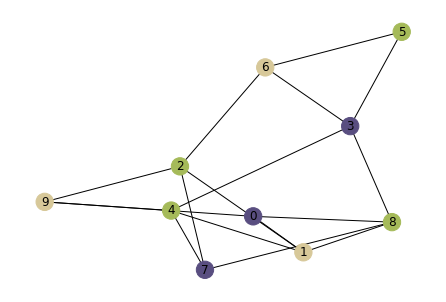

In [812]:
print(C, [u for u in Vp if G.degree(u)>=len(C)], [u for u in Vp if G.degree(u)<len(C)])
nx.draw(G, with_labels=True, node_color=get_colors_to_use(f))

In [814]:
f

{0: 1, 1: 3, 2: 2, 3: 1, 4: 2, 5: 2, 6: 3, 7: 1, 8: 2, 9: 3}

{1, 2, 3, 4} [0, 2, 3, 6]


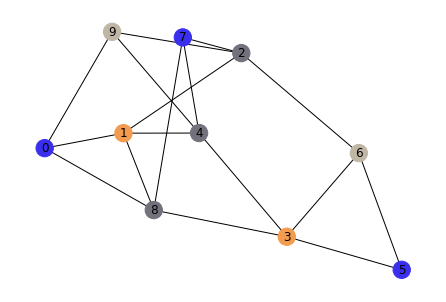

In [818]:
print(set(fc.values()), Bp)
nx.draw(G, with_labels=True, node_color=get_colors_to_use(fc))

In [465]:
fc

{0: 1, 1: 2, 2: 3, 3: 4, 4: 3, 5: 5, 6: 5, 7: 1, 8: 2, 9: 3}

#### TEST 2:
#### (1) WE ADD COLOUR K+1 TO B-CHROMATIC CANDIDATES
#### (2) WE FIND A B-CHROMATIC VERTEX OF COLOUR K+1

In [822]:
n = 10
#G = nx.random_graphs.gnp_random_graph(n, 0.5)
print("m(G)={}".format(get_m_degree(G)))

#Initial colouring
f = {u:j+1 for j, u in enumerate(G.nodes())}
fp = partition_redistribution(G, f)

#re indexing colours
g = {u:i+1 for i, u in enumerate(set(fp.values()))}
for u in G:
    f[u] = g[fp[u]]

Vp = get_b_chromatic_vertices(G, f)
assert is_proper(G, f)
assert are_b_chromatic(G, f, Vp)#We test if the colouring return by the partition redistribution is b-chromatic

print("PREPROCESSING")
V, BD, C, Cp, Cpp, F = preprocessing(G, f)

#AUXILIAR DICTIONARY FOR BIPARTITE GRAPH H
bipartites_graphs = {c:{"H":None, "X":None, "Y":None, "M":None} for c in C.union({len(C)+1})}

fc = copy.deepcopy(f)
b_chromatic = {u:False for u in G}

print("STAGE (1)")
fc, Cpp, F, b_chromatic, bipartites_graphs = add_colour_k_plus_1(G, C, Cp, Cpp, V, fc, BD, F,
                                                                 b_chromatic, bipartites_graphs)

print("STAGE (2)")
Cpp = Cpp.union({len(C)+1})
success, fc, b_chromatic, F, bipartites_graphs = find_b_chromatic_k_plus_1( G, V, C, Cpp, fc, F, 
                                                                            b_chromatic, 
                                                                            bipartites_graphs)

Bp = [u for u in G if b_chromatic[u]]

if success:
    assert is_proper(G, fc), "Colouring is not proper"
    assert are_b_chromatic(G, fc, Bp), "Not enough b-chromatic vertices of all the colours"
    print("COLOURING EXTENDED!")
else: print("NO EXTENSION!")

m(G)=5
PREPROCESSING
(5, 0, 6, 7, 9, 1, 2, 3, 4, 8)
STAGE (1)
Looking for a b-chromatic vertex of colour 1
Colour of 0: 1 
	 Assigning to N(0) colours: {2, 3, 4}
	 f[9] = 4
	 f[8] = 2
	 f[1] = 3
Looking for a b-chromatic vertex of colour 2
Colour of 2: 2 
	 Assigning to N(2) colours: {1, 3, 4}
	 f[7] = 1
	 f[1] = 3
	 f[6] = 4
Looking for a b-chromatic vertex of colour 3
STAGE (2)
Looking for a b-chromatic vertex of colour 3
We change the colour of 3 from 1 to 3
Not possible to find a b-chromatic colouring for colour 3
NO EXTENSION!


### TESTING ON A REAL WORLD GRAPH

#### Reading the graph

In [85]:
name_list = os.listdir("./graphs_datasets/DIMACS/")
graphs_list = [name for name in name_list if name[-3:]=="col"]
graphs_list

['flat1000_50_0.col',
 'le450_25.d.col',
 'DSJR500.5.col',
 'R250.5.col',
 'le450_25.c.col',
 'flat300_28_0.col',
 'myciel5.col',
 'myciel4.col',
 'myciel6.col',
 'myciel7.col',
 'myciel3.col',
 'miles1000.col',
 'DSJC250.5.col',
 'miles250.col',
 'queen6.col',
 'queen10.col',
 'queen5.col',
 'DSJC500.5.col',
 'DSJC500.1.col']

In [419]:
other_papers_res = {
    'flat1000_50_0.col':{"phiG":139, "t(s)":58427.97, "ALG":"H"},
    'le450_25.d.col':{"phiG":45, "t(s)":256.42, "ALG":"H"},
    'DSJR500.5.col':{"phiG":166, "t(s)":15007.00, "ALG":"H"},
    'R250.5.col':{"phiG":92, "t(s)":1836.16, "ALG":"H"},
    'le450_25.c.col':{"phiG":45, "t(s)":571.72, "ALG":"H"},
    'flat300_28_0.col':{"phiG":55, "t(s)":1048.04, "ALG":"H"},
    'myciel5.col':{"phiG":8, "t(s)":0.7513, "ALG":"Q"},
    'myciel4.col':{"phiG":6, "t(s)":0.5419, "ALG":"Q"},
    'myciel6.col':{"phiG":13, "t(s)":1.8345, "ALG":"Q"},
    'myciel7.col':{"phiG":16, "t(s)":11.3901, "ALG":"Q"},
    'myciel3.col':{"phiG":4, "t(s)":0.4166, "ALG":"Q"},
    'miles1000.col':{"phiG":47, "t(s)":4.2587, "ALG":"Q"},
    'DSJC250.5.col':{"phiG":50, "t(s)":186.84, "ALG":"H"},
    'miles250.col':{"phiG":12, "t(s)":0.5527, "ALG":"Q"},
    'queen6.col':{"phiG":11, "t(s)":0.8934, "ALG":"Q"},
    'queen10.col':{"phiG":18, "t(s)":3.5566, "ALG":"Q"},
    'queen5.col':{"phiG":9, "t(s)":0.4326, "ALG":"Q"},
    'DSJC500.5.col':{"phiG":84, "t(s)":4506.87, "ALG":"H"},
    'DSJC500.1.col':{"phiG":25, "t(s)":113.61, "ALG":"H"}
}

In [87]:
def read_graph(name):
    dir = "./graphs_datasets/DIMACS"
    file = "{}/{}"
    with open(file.format(dir, name), 'r') as f:
        while(True):
            line = f.readline()
            if line == "": break
            if line[0] == "p":
                _, _, n, m = line.split()
                n = int(n)
                m = int(m)
                G = nx.Graph()
                for i in range(1, n+1): G.add_node(i)
            elif line[0] == "e": 
                _, u, v = line.split()
                G.add_edge(int(u), int(v))
    return G

#### Computing the biggest connected component

In [88]:
def get_biggest_cc(G):
    if not nx.is_connected(G):
        CC = list(nx.connected_components(G))
        i_max = 0
        for i, cc in enumerate(CC):
            if len(cc) >= len(CC[i_max]):
                i_max = i
        CCmax = CC[i_max]
        G = nx.induced_subgraph(G, CCmax)
    return G

##### Getting an intial colouring

In [301]:
#Initial colouring
Gtest = read_graph("DSJC500.1.col")
f = {u:j+1 for j, u in enumerate(Gtest.nodes())}
fp = partition_redistribution3(Gtest, f)

#re indexing colours
g = {u:i+1 for i, u in enumerate(set(fp.values()))}
for u in Gtest:
    f[u] = g[fp[u]]

Vp = get_b_chromatic_vertices(Gtest, f)
#print(Vp)
assert is_proper(Gtest, f)
assert are_b_chromatic(Gtest, f, Vp)#We test if the colouring return by the partition redistribution is b-chromatic
print("m(G): {}".format(get_m_degree(Gtest)))
print("COLOURING WITH PARTITION REDISTRIBUTION: {}".format(len(set(f.values()))))

m(G): 59
COLOURING WITH PARTITION REDISTRIBUTION: 23


##### Extending the colouring

In [125]:
fc1 = copy.deepcopy(f)

In [130]:
fc1 = extend_b_chromatic_colouring_by_one1(Gtest, fc1)
if fc1 != None: print(len(set(fc1.values())))

NO EXTENSION!


In [139]:
fc2 = copy.deepcopy(f)

In [145]:
fc2 = extend_b_chromatic_colouring_by_one2(Gtest, fc2)
if fc2 is not None: print(len(set(fc2.values())))

STILL 6 B-CHROMATIC VERTICES TO FOUND - NO EXTENSION!
NO EXTENSION!


##### TESTING PR

In [416]:
def test_partition_redistribution(G, pr_function):
    #Initial colouring
    f = {u:j+1 for j, u in enumerate(G.nodes())}
    start = time.time()
    fp = pr_function(G, f)
    end = time.time()

    #re indexing colours
    g = {u:i+1 for i, u in enumerate(set(fp.values()))}
    for u in G:
        f[u] = g[fp[u]]

    Vp = get_b_chromatic_vertices(G, f)
    assert is_proper(G, f)
    assert are_b_chromatic(G, f, Vp)

    k = len(set(f.values()))

    return k, end-start

In [513]:
results_pr = { "G":[],
               "V(G)":[],
               "E(G)":[],
               "DENSITY(G)":[],
               "m(G)":[],
               "PR1(G)":[],
               "TPR1(s)":[],
               "PR2(G)":[],
               "TPR2(s)":[],
               "PR3(G)":[],
               "TPR3(s)":[],
               "QuickBcol":[],
               "TQ(s)":[],
               "HEA_b":[],
               "TH(s)":[]}
for gname in graphs_list:
    print("Computing on graph: {}".format(gname))
    G = read_graph(gname)
    G = get_biggest_cc(G)
    results_pr["G"].append(gname)
    results_pr["V(G)"].append(G.number_of_nodes())
    results_pr["E(G)"].append(G.number_of_edges())
    results_pr["m(G)"].append(get_m_degree(G))
    results_pr["DENSITY(G)"].append(2*G.number_of_edges()/(G.number_of_nodes()*(G.number_of_nodes()-1)))
    if other_papers_res[gname]["ALG"] == "Q":
        results_pr["QuickBcol"].append(other_papers_res[gname]["phiG"])
        results_pr["TQ(s)"].append(other_papers_res[gname]["t(s)"])
        results_pr["HEA_b"].append("-")
        results_pr["TH(s)"].append("-")
    else:
        results_pr["HEA_b"].append(other_papers_res[gname]["phiG"])
        results_pr["TH(s)"].append(other_papers_res[gname]["t(s)"])
        results_pr["QuickBcol"].append("-")
        results_pr["TQ(s)"].append("-")
    
    k, total_time = test_partition_redistribution(G, partition_redistribution)
    results_pr["PR1(G)"].append(k)
    results_pr["TPR1(s)"].append(total_time)

    k, total_time = test_partition_redistribution(G, partition_redistribution2)
    results_pr["PR2(G)"].append(k)
    results_pr["TPR2(s)"].append(total_time)

    k, total_time = test_partition_redistribution(G, partition_redistribution3)
    results_pr["PR3(G)"].append(k)
    results_pr["TPR3(s)"].append(total_time)

Computing on graph: flat1000_50_0.col
Computing on graph: le450_25.d.col
Computing on graph: DSJR500.5.col
Computing on graph: R250.5.col
Computing on graph: le450_25.c.col
Computing on graph: flat300_28_0.col
Computing on graph: myciel5.col
Computing on graph: myciel4.col
Computing on graph: myciel6.col
Computing on graph: myciel7.col
Computing on graph: myciel3.col
Computing on graph: miles1000.col
Computing on graph: DSJC250.5.col
Computing on graph: miles250.col
Computing on graph: queen6.col
Computing on graph: queen10.col
Computing on graph: queen5.col
Computing on graph: DSJC500.5.col
Computing on graph: DSJC500.1.col


In [514]:
df_pr = pd.DataFrame(results_pr)
df_pr

,G,V(G),E(G),DENSITY(G),m(G),PR1(G),TPR1(s),PR2(G),TPR2(s),PR3(G),TPR3(s),QuickBcol,TQ(s),HEA_b,TH(s)
0,flat1000_50_0.col,1000,245000,0.490490,492,137,0.327118,140,69.063403,135,167.247712,-,-,139,58427.97
1,le450_25.d.col,450,17425,0.172482,99,41,0.060907,42,3.433811,42,8.758013,-,-,45,256.42
2,DSJR500.5.col,500,58862,0.471840,234,159,0.052120,164,5.739338,176,14.071919,-,-,166,15007.0
3,R250.5.col,250,14849,0.477076,119,81,0.013130,85,0.695258,96,1.597280,-,-,92,1836.16
4,le450_25.c.col,450,17343,0.171670,101,42,0.063412,41,3.439267,43,8.732808,-,-,45,571.72
5,flat300_28_0.col,300,21695,0.483724,146,51,0.025418,51,1.529499,50,3.636698,-,-,55,1048.04
6,myciel5.col,47,236,0.218316,13,6,0.000965,6,0.005953,8,0.013523,8,0.7513,-,-
7,myciel4.col,23,71,0.280632,7,5,0.000277,5,0.001047,5,0.002279,6,0.5419,-,-
8,myciel6.col,95,755,0.169093,21,7,0.003748,9,0.036030,10,0.087702,13,1.8345,-,-
9,myciel7.col,191,2360,0.130063,35,10,0.013209,13,0.238590,16,0.591835,16,11.3901,-,-


#### Results prioritizing colour in PR3

In [510]:
pd.DataFrame(results_pr)

,G,V(G),E(G),DENSITY(G),m(G),PR1(G),TPR1(s),PR2(G),TPR2(s),PR3(G),TPR3(s),QuickBcol,TQ(s),HEA_b,TH(s)
0,flat1000_50_0.col,1000,245000,0.490490,492,137,0.306429,140,68.075168,132,182.937973,-,-,139,58427.97
1,le450_25.d.col,450,17425,0.172482,99,41,0.062363,42,3.452341,37,10.341219,-,-,45,256.42
2,DSJR500.5.col,500,58862,0.471840,234,159,0.051722,164,5.851204,141,15.852412,-,-,166,15007.0
3,R250.5.col,250,14849,0.477076,119,81,0.013308,85,0.694757,74,1.864236,-,-,92,1836.16
4,le450_25.c.col,450,17343,0.171670,101,42,0.065592,41,3.489757,36,10.227777,-,-,45,571.72
5,flat300_28_0.col,300,21695,0.483724,146,51,0.026857,51,1.540473,49,4.171617,-,-,55,1048.04
6,myciel5.col,47,236,0.218316,13,6,0.001097,6,0.006818,6,0.023033,8,0.7513,-,-
7,myciel4.col,23,71,0.280632,7,5,0.000316,5,0.001198,5,0.003294,6,0.5419,-,-
8,myciel6.col,95,755,0.169093,21,7,0.004283,9,0.041052,7,0.143412,13,1.8345,-,-
9,myciel7.col,191,2360,0.130063,35,10,0.013236,13,0.239244,9,1.090202,16,11.3901,-,-


#### Results prioritizing colour in PR2

In [497]:
pd.DataFrame(results_pr)

,G,V(G),E(G),DENSITY(G),m(G),PR1(G),TPR1(s),PR2(G),TPR2(s),PR3(G),TPR3(s),QuickBcol,TQ(s),HEA_b,TH(s)
0,flat1000_50_0.col,1000,245000,0.490490,492,137,0.317381,127,69.743462,135,168.762783,-,-,139,58427.97
1,le450_25.d.col,450,17425,0.172482,99,41,0.062111,37,3.727104,42,8.875853,-,-,45,256.42
2,DSJR500.5.col,500,58862,0.471840,234,159,0.053532,159,6.018310,176,14.358384,-,-,166,15007.0
3,R250.5.col,250,14849,0.477076,119,81,0.013199,82,0.722893,96,1.606570,-,-,92,1836.16
4,le450_25.c.col,450,17343,0.171670,101,42,0.065633,36,3.825374,43,8.849696,-,-,45,571.72
5,flat300_28_0.col,300,21695,0.483724,146,51,0.025412,48,1.602045,50,3.712043,-,-,55,1048.04
6,myciel5.col,47,236,0.218316,13,6,0.000967,6,0.007510,8,0.013502,8,0.7513,-,-
7,myciel4.col,23,71,0.280632,7,5,0.000280,5,0.001163,5,0.002287,6,0.5419,-,-
8,myciel6.col,95,755,0.169093,21,7,0.003788,7,0.046970,10,0.088338,13,1.8345,-,-
9,myciel7.col,191,2360,0.130063,35,10,0.013289,8,0.321308,16,0.594560,16,11.3901,-,-


In [429]:
df_pr.to_csv("partition_redistribution_results.csv")

In [17]:
Gtest = read_graph("myciel4.col")

In [19]:
get_m_degree_2(Gtest)

7

In [25]:
du_dict = {u:Gtest.degree(u) for u in Gtest}
dict(sorted(du_dict.items(), key=lambda x:x[1], reverse=True))

{23: 11,
 11: 10,
 1: 8,
 2: 8,
 3: 8,
 4: 8,
 5: 8,
 6: 6,
 7: 6,
 8: 6,
 9: 6,
 10: 6,
 22: 6,
 12: 5,
 13: 5,
 14: 5,
 15: 5,
 16: 5,
 17: 4,
 18: 4,
 19: 4,
 20: 4,
 21: 4}

##### TESTING PR, EXT1 AND EXT2

In [188]:
results = {"G":[],
           "V(G)":[],
           "E(G)":[],
           "DENSITY(G)":[],
           "MAX_D(G)":[],
           "MIN_D(G)":[],
           "m(G)":[],
           "PR1(G)":[],
           "TPR(s)":[],
           "PR2(G)":[],
           "TPR(s)":[],
           "PR3(G)":[],
           "TPR(s)":[],
           "EXT1(G)":[],
           "T1(s)":[],
           "EXT2(G)":[],
           "T2(s)":[]}
for gname in graphs_list:
    G = read_graph(gname)
    G = get_biggest_cc(G)
    VGi = G.number_of_nodes()
    EGi = G.number_of_edges()
    results["G"].append(gname)
    results["V(G)"].append(VGi)
    results["E(G)"].append(EGi)
    results["DENSITY(G)"].append(2*EGi/(VGi*(VGi-1)))
    results["MAX_D(G)"].append(max([G.degree(u) for u in G]))
    results["MIN_D(G)"].append(min([G.degree(u) for u in G]))
    results["m(G)"].append(get_m_degree(G))
    #Initial colouring
    f = {u:j+1 for j, u in enumerate(G.nodes())}
    start = time.time()
    fp = partition_redistribution(G, f)
    end = time.time()
    results["TPR(s)"].append(end-start)

    #re indexing colours
    g = {u:i+1 for i, u in enumerate(set(fp.values()))}
    for u in G:
        f[u] = g[fp[u]]
    results["PR(G)"].append(len(set(f.values())))

    Vp = get_b_chromatic_vertices(G, f)
    assert is_proper(G, f)
    assert are_b_chromatic(G, f, Vp)

    #TESTING EXTENSION HEURISTIC 1
    fc1 = copy.deepcopy(f)
    total_time = 0
    b_chr_ext = None
    while(True):
        start = time.time()
        fc1 = extend_b_chromatic_colouring_by_one1(G, fc1)
        end = time.time()
        if fc1 is None: 
            if b_chr_ext is None: results["EXT1(G)"].append("NO_EXT")
            else: results["EXT1(G)"].append(b_chr_ext)
            break
        else:
            if b_chr_ext is None:
                b_chr_ext = len(set(fc1.values()))
            else: b_chr_ext += 1
        total_time += end-start
    results["T1(s)"].append(total_time)

    #TESTING EXTENSION HEURISTIC 2
    fc2 = copy.deepcopy(f)
    total_time = 0
    b_chr_ext = None
    while(True):
        start = time.time()
        fc2 = extend_b_chromatic_colouring_by_one2(G, fc2)
        end = time.time()
        if fc2 is None: 
            if b_chr_ext is None: results["EXT2(G)"].append("NO_EXT")
            else: results["EXT2(G)"].append(b_chr_ext)
            break
        else:
            if b_chr_ext is None:
                b_chr_ext = len(set(fc2.values()))
            else: b_chr_ext += 1
        total_time += end-start
    results["T2(s)"].append(total_time)

COLOURING EXTENDED!
COLOURING EXTENDED!
NO EXTENSION!
STILL 4 B-CHROMATIC VERTICES TO FOUND - NO EXTENSION!
NO EXTENSION!
COLOURING EXTENDED!
NO EXTENSION!
STILL 1 B-CHROMATIC VERTICES TO FOUND - NO EXTENSION!
COLOURING EXTENDED!
COLOURING EXTENDED!
COLOURING EXTENDED!
COLOURING EXTENDED!
COLOURING EXTENDED!
STILL 1 B-CHROMATIC VERTICES TO FOUND - NO EXTENSION!
NO EXTENSION!
NO EXTENSION!
STILL 1 B-CHROMATIC VERTICES TO FOUND - NO EXTENSION!
NO EXTENSION!
NO EXTENSION!
COLOURING EXTENDED!
COLOURING EXTENDED!
COLOURING EXTENDED!
STILL 4 B-CHROMATIC VERTICES TO FOUND - NO EXTENSION!
NO EXTENSION!
COLOURING EXTENDED!
COLOURING EXTENDED!
NO EXTENSION!
COLOURING EXTENDED!
COLOURING EXTENDED!
COLOURING EXTENDED!
COLOURING EXTENDED!
COLOURING EXTENDED!
STILL 3 B-CHROMATIC VERTICES TO FOUND - NO EXTENSION!
NO EXTENSION!
NO EXTENSION!
STILL 1 B-CHROMATIC VERTICES TO FOUND - NO EXTENSION!
NO EXTENSION!
NO EXTENSION!
STILL 3 B-CHROMATIC VERTICES TO FOUND - NO EXTENSION!
NO EXTENSION!
NO EXTENSION

In [189]:
pd.DataFrame(results)

,G,V(G),E(G),DENSITY(G),MAX_D(G),MIN_D(G),m(G),PR(G),TPR(s),EXT1(G),T1(s),EXT2(G),T2(s)
0,flat1000_50_0.col,1000,245000,0.490490,520,459,492,122,0.795810,124,117.536529,NO_EXT,0.000000
1,le450_25.d.col,450,17425,0.172482,157,11,99,34,0.234573,35,0.291235,39,1.751079
2,DSJR500.5.col,500,58862,0.471840,388,103,234,143,0.081381,NO_EXT,0.000000,NO_EXT,0.000000
3,R250.5.col,250,14849,0.477076,191,53,119,77,0.015270,NO_EXT,0.000000,80,9.275437
4,le450_25.c.col,450,17343,0.171670,179,7,101,34,0.250586,36,0.649073,39,1.670161
5,flat300_28_0.col,300,21695,0.483724,162,130,146,46,0.044038,NO_EXT,0.000000,NO_EXT,0.000000
6,myciel5.col,47,236,0.218316,23,5,13,6,0.001505,NO_EXT,0.000000,NO_EXT,0.000000
7,myciel4.col,23,71,0.280632,11,4,7,5,0.000361,NO_EXT,0.000000,NO_EXT,0.000000
8,myciel6.col,95,755,0.169093,47,6,21,7,0.009732,NO_EXT,0.000000,8,0.016762
9,myciel7.col,191,2360,0.130063,95,7,35,8,0.039800,NO_EXT,0.000000,10,0.064675


In [180]:
pd.DataFrame(results)

,G,V(G),E(G),DENSITY(G),MAX_D(G),MIN_D(G),m(G),PR(G),TPR(s),EXT1(G),T1(s),EXT2(G),T2(s)
0,flat1000_50_0.col,1000,245000,0.490490,520,459,492,137,0.301129,NO_EXT,0.000000,NO_EXT,0.000000
1,le450_25.d.col,450,17425,0.172482,157,11,99,41,0.062918,42,0.546053,NO_EXT,0.000000
2,DSJR500.5.col,500,58862,0.471840,388,103,234,159,0.053327,NO_EXT,0.000000,NO_EXT,0.000000
3,R250.5.col,250,14849,0.477076,191,53,119,81,0.013142,NO_EXT,0.000000,82,3.355114
4,le450_25.c.col,450,17343,0.171670,179,7,101,42,0.066712,NO_EXT,0.000000,NO_EXT,0.000000
5,flat300_28_0.col,300,21695,0.483724,162,130,146,51,0.025879,NO_EXT,0.000000,NO_EXT,0.000000
6,myciel5.col,47,236,0.218316,23,5,13,6,0.000969,7,0.008659,7,0.005398
7,myciel4.col,23,71,0.280632,11,4,7,5,0.000495,NO_EXT,0.000000,NO_EXT,0.000000
8,myciel6.col,95,755,0.169093,47,6,21,7,0.006314,8,0.006403,NO_EXT,0.000000
9,myciel7.col,191,2360,0.130063,95,7,35,10,0.015495,NO_EXT,0.000000,NO_EXT,0.000000


In [163]:
df = pd.DataFrame(results)
df

,G,V(G),E(G),DENSITY(G),MAX_D(G),MIN_D(G),m(G),PR(G),TPR(s),EXT1(G),T1(s),EXT2(G),T2(s)
0,flat1000_50_0.col,1000,245000,0.490490,520,459,492,137,0.314785,NO_EXT,0.000000,NO_EXT,0.000000
1,le450_25.d.col,450,17425,0.172482,157,11,99,41,0.064309,42,0.548046,NO_EXT,0.000000
2,DSJR500.5.col,500,58862,0.471840,388,103,234,159,0.052745,NO_EXT,0.000000,NO_EXT,0.000000
3,R250.5.col,250,14849,0.477076,191,53,119,81,0.013688,NO_EXT,0.000000,82,3.365397
4,le450_25.c.col,450,17343,0.171670,179,7,101,42,0.067209,NO_EXT,0.000000,NO_EXT,0.000000
5,flat300_28_0.col,300,21695,0.483724,162,130,146,51,0.026229,NO_EXT,0.000000,NO_EXT,0.000000
6,myciel5.col,47,236,0.218316,23,5,13,6,0.001003,7,0.002223,7,0.002065
7,myciel4.col,23,71,0.280632,11,4,7,5,0.000281,NO_EXT,0.000000,NO_EXT,0.000000
8,myciel6.col,95,755,0.169093,47,6,21,7,0.005442,8,0.008616,NO_EXT,0.000000
9,myciel7.col,191,2360,0.130063,95,7,35,10,0.015879,NO_EXT,0.000000,NO_EXT,0.000000


In [934]:
df.to_csv("./graphs_datasets/DIMACS/results.csv")

### TESTING MULTIPLE EXTENSIONS

In [99]:
for u in G:
    print("{}, ".format(u), end="")
print()
for x,y in G.edges():
    print("({},{}), ".format(x,y), end="")

0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 
(0,1), (0,2), (0,4), (0,5), (0,8), (1,2), (1,3), (1,6), (1,8), (2,3), (2,4), (2,6), (2,9), (3,4), (3,5), (4,7), (4,8), (5,6), (5,8), (5,9), (6,9), (8,9), 

In [11]:
node_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
edge_list = [(0,1), (0,2), (0,4), (0,5), (0,8), (1,2), (1,3), (1,6), (1,8), (2,3), (2,4), (2,6), (2,9), (3,4), (3,5), (4,7), (4,8), (5,6), (5,8), (5,9), (6,9), (8,9)]
G = nx.Graph()
G.add_nodes_from(node_list)
G.add_edges_from(edge_list)
G

In [156]:
n = 10
G = nx.random_graphs.gnp_random_graph(n, 0.5)
print("m(G)={}".format(get_m_degree(G)))

#Initial colouring
f = {u:j+1 for j, u in enumerate(G.nodes())}
fp = partition_redistribution(G, f)

#re indexing colours
g = {u:i+1 for i, u in enumerate(set(fp.values()))}
for u in G:
    f[u] = g[fp[u]]

Vp = get_b_chromatic_vertices(G, f)
assert are_b_chromatic(G, f, Vp)

print("METHOD (1)")
fc1 = extend_b_chromatic_colouring_by_one1(G, f)
print("METHOD (2)")
fc2 = extend_b_chromatic_colouring_by_one2(G, f)


m(G)=5
METHOD (1)
COLOURING EXTENDED!
METHOD (2)
STILL 1 B-CHROMATIC VERTICES TO FOUND - NO EXTENSION!
COLOURING EXTENDED!


{1, 2, 3, 4}
1
vertex 1 has colour 1 on its neighbourhood
vertex 2 has colour 1 on its neighbourhood
vertex 5 has colour 1 on its neighbourhood
2
vertex 1 has colour 2 on its neighbourhood
vertex 5 has colour 2 on its neighbourhood
vertex 9 has colour 2 on its neighbourhood
3
vertex 2 has colour 3 on its neighbourhood
vertex 5 has colour 3 on its neighbourhood
4
vertex 2 has colour 4 on its neighbourhood
vertex 9 has colour 4 on its neighbourhood


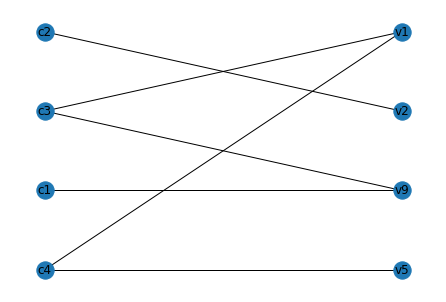

In [13]:
fp = copy.deepcopy(f)
k = len(set(f.values()))
u = 6
fp[u] = k+1
F = {v:False for v in G}
NCu = set(f.values()).union({k+1}).difference({fp[u]})
print(NCu)
H, X, Y = getH(G, u, fp, NCu, F)
Hn = getNXgraph(H)
nx.draw(Hn, with_labels=True, pos=nx.drawing.bipartite_layout(Hn,X))

In [14]:
H

{'v1': [],
 'v2': [],
 'v5': [],
 'v9': [],
 'c2': ['v2'],
 'c3': ['v1', 'v9'],
 'c4': ['v1', 'v5']}

In [14]:
f

{0: 1, 1: 3, 2: 2, 3: 1, 4: 4, 5: 4, 6: 1, 7: 1, 8: 2, 9: 3}

In [44]:
set(f.values())

{1, 2, 3, 4, 5}

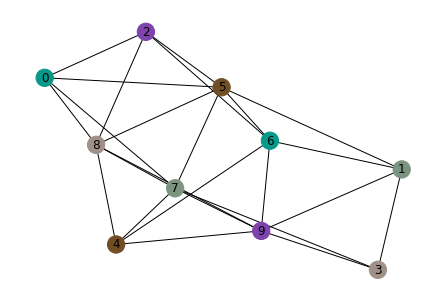

In [31]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(fc2))

In [30]:
get_b_chromatic_vertices(G, fc2)

[0, 1, 4, 5, 7, 8, 9]

### EXPERIMENT

In [186]:
import sys
N = 15 #number of trials
results = {"#vertices":[],
           "density":[],
           "AVG_#edges":[],
           "AVG_MAXDegree": [],
           "AVG_mDegree":[],
           "AVGDenseVertices":[],
           "AVG_B_CHR_PR":[],
           "AVG_EXT_M1":[],
           "AVG_EXT_M2":[]}
densities = [0.05, 0.1, 0.25, 0.5]
#L1 = [i for i in range(50, 60, 10)]
L = [i for i in range(100, 250, 10)]
#L = L1+L2
for n in L:
    for d in densities:
        aux_results = {key:0 for key in results.keys() if key != "#vertices" and key != "density"}
        results["#vertices"].append(n)
        results["density"].append(d)
        sys.stdout.write('\r'+"Running for random graphs with {} vertices and density {}\n".format(n, d))
        for i in range(N):
            Gi = nx.random_graphs.gnp_random_graph(n, d)
            aux_results["AVG_#edges"] += Gi.number_of_edges()
            aux_results["AVG_MAXDegree"] += max([Gi.degree[u] for u in Gi])
            mi = get_m_degree(Gi)
            aux_results["AVG_mDegree"] += mi

            VDi = get_dense_vertices(Gi, mi)
            aux_results["AVGDenseVertices"] += len(VDi)

            #Initial colouring
            fi = {u:j+1 for j, u in enumerate(Gi.nodes())}
            fpi = partition_redistribution(Gi, fi)

            #re indexing colours
            gi = {u:i+1 for i, u in enumerate(set(fpi.values()))}
            for u in Gi:
                fi[u] = gi[fpi[u]]

            Vpi = get_b_chromatic_vertices(Gi, fi)
            assert is_proper(Gi, fi)
            assert are_b_chromatic(Gi, fi, Vpi)
            aux_results["AVG_B_CHR_PR"] += len(set(fi.values()))
            
            fci1 = copy.deepcopy(fi)
            n_ext, totalt = extend_colouring(Gi, fci1, extend_b_chromatic_colouring_by_one1)
            aux_results["AVG_EXT_M1"] += n_ext

            #fci1 = extend_b_chromatic_colouring_by_one1(Gi, fi)
            #if fci1 is not None:
            #    aux_results["AVG_EXT_M1"] += 1
            if fi is None:print("YES")
            fci2 = copy.deepcopy(fi)
            n_ext, totalt = extend_colouring(Gi, fci2, extend_b_chromatic_colouring_by_one2)
            aux_results["AVG_EXT_M2"] += n_ext
            
            #fci2 = extend_b_chromatic_colouring_by_one2(Gi, fi)
            #if fci1 is not None:
            #    aux_results["AVG_EXT_M2"] += 1
                
        for key in aux_results.keys():
            results[key].append(aux_results[key]/N)
        


Running for random graphs with 100 vertices and density 0.05
COLOURING EXTENDED!
COLOURING EXTENDED!
NO EXTENSION!


AttributeError: 'NoneType' object has no attribute 'values'

In [178]:
df = pd.DataFrame(results)
df

,#vertices,density,AVG_#edges,AVG_MAXDegree,AVG_mDegree,AVGDenseVertices,AVG_B_CHR_PR,AVG_EXT_M1,AVG_EXT_M2
0,100,0.05,249.933333,10.600000,9.000000,13.733333,5.866667,1.000000,1.000000
1,100,0.10,500.933333,17.666667,14.400000,17.400000,7.866667,1.000000,1.000000
2,100,0.25,1241.666667,36.600000,28.266667,32.333333,13.600000,0.266667,0.266667
3,100,0.50,2471.000000,61.066667,50.333333,55.333333,21.800000,0.000000,0.000000
4,110,0.05,300.133333,11.666667,9.600000,14.133333,6.000000,1.000000,1.000000
5,110,0.10,598.133333,19.800000,15.266667,19.933333,8.066667,1.000000,1.000000
6,110,0.25,1500.000000,39.400000,30.866667,35.533333,13.933333,0.666667,0.666667
7,110,0.50,2997.133333,67.200000,55.400000,59.733333,23.200000,0.000000,0.000000
8,120,0.05,357.400000,12.666667,10.333333,13.866667,6.133333,1.000000,1.000000
9,120,0.10,720.000000,21.400000,16.600000,21.800000,8.466667,1.000000,1.000000


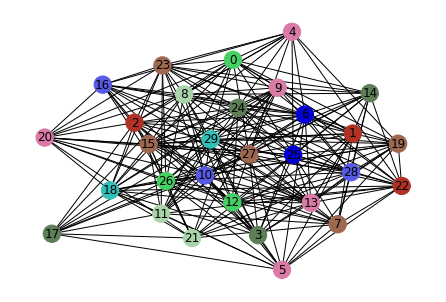

In [431]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(fc))

{'c3': 'v1', 'c8': 'v10', 'c1': 'v9', 'c5': 'v6', 'c2': 'v8', 'c7': 'v7', 'c6': 'v0'}


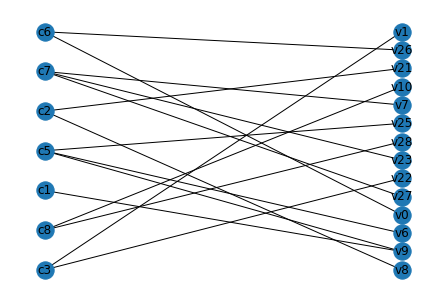

In [435]:
cp = 4
Hp = bipartites_graphs[cp]["H"]
NHp = getNXgraph(Hp)
Xp = bipartites_graphs[cp]["X"]
Yp = bipartites_graphs[cp]["Y"]
print(bipartites_graphs[cp]["M"])
nx.draw(NHp, with_labels=True, pos=nx.drawing.bipartite_layout(NHp,Xp))

In [121]:
G[13]

AtlasView({8: {}, 11: {}})

In [118]:
fc

{0: 6,
 1: 3,
 2: 1,
 3: 1,
 4: 3,
 5: 4,
 6: 4,
 7: 6,
 8: 5,
 9: 2,
 10: 1,
 11: 2,
 12: 4,
 13: 4,
 14: 5}

[('s', 'c6', 'v7', 't'), ('s', 'c5', 'v0', 't'), ('s', 'c4', 'v6', 't'), ('s', 'c3', 'v3', 't'), ('s', 'c2', 'v5', 't')]


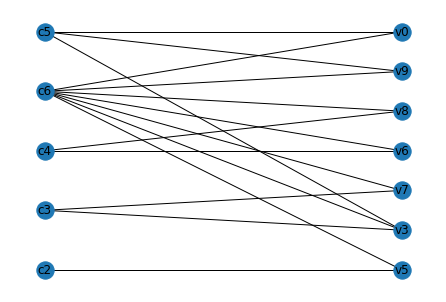

In [57]:
cp = 1
Hp = bipartites_graphs[cp]["H"]
NHp = getNXgraph(Hp)
Xp = bipartites_graphs[cp]["X"]
Yp = bipartites_graphs[cp]["Y"]
print(bipartites_graphs[cp]["M"])
nx.draw(NHp, with_labels=True, pos=nx.drawing.bipartite_layout(NHp,Xp))

## Heuristic for finding a b-chromatic colouring using $m(G)$ colours based on connected components

In [442]:
n = 500
G = nx.random_graphs.gnp_random_graph(n, 0.5)
m = get_m_degree(G)
Vp = {u:G.degree(u) for u in G if G.degree(u) >= m-1}
Vp = dict(sorted(Vp.items(), key=lambda x:x[1]), reverse=True)
VC = list(Vp.keys())[:m]
print("m(G):{}\nD: {}\nVC:{}".format(m, Vp.keys(), VC))
S = set(G.nodes())
for u in VC:
    NVC = {v for v in G.adj[u]}
    S = S.intersection(NVC)
print(len(S))

m(G):251
D: dict_keys([1, 14, 45, 53, 115, 247, 269, 337, 383, 407, 420, 428, 459, 465, 492, 23, 46, 71, 74, 92, 117, 119, 131, 145, 153, 156, 181, 183, 255, 293, 299, 306, 339, 345, 347, 359, 368, 387, 406, 457, 474, 10, 47, 48, 56, 124, 165, 231, 263, 268, 291, 304, 348, 432, 463, 464, 475, 11, 39, 42, 65, 100, 106, 133, 142, 177, 186, 216, 239, 240, 249, 426, 441, 444, 69, 84, 155, 194, 199, 242, 245, 321, 329, 365, 405, 411, 460, 0, 33, 73, 104, 210, 259, 262, 271, 326, 360, 362, 381, 417, 423, 25, 72, 161, 162, 237, 238, 246, 260, 286, 323, 328, 336, 346, 398, 435, 445, 455, 479, 487, 491, 29, 90, 96, 111, 159, 163, 172, 179, 218, 232, 279, 282, 284, 349, 436, 32, 64, 150, 250, 312, 313, 324, 371, 419, 438, 485, 2, 3, 35, 85, 101, 118, 190, 200, 203, 389, 393, 404, 446, 449, 473, 18, 125, 137, 157, 213, 230, 253, 265, 294, 314, 340, 361, 379, 414, 442, 13, 31, 75, 144, 147, 277, 278, 289, 355, 430, 58, 136, 198, 233, 274, 292, 369, 403, 409, 416, 440, 488, 38, 40, 154, 176, 276, 2

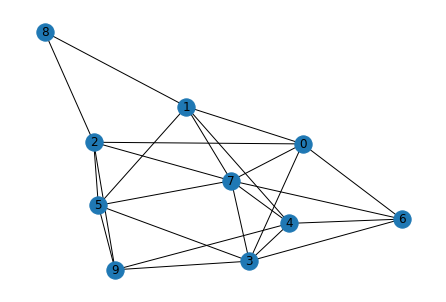

In [433]:
nx.draw(G, with_labels=True)